# Tutorial 5

**Name:** Dharmraj Sodha

## Import libraries

In [26]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Exercise 1: Implement K-Means Clustering

### 1. Load Iris dataset

In [27]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print('Shape of iris dataset:', X.shape)
X.head()

Shape of iris dataset: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 2. Apply K-Means with fixed number of clusters (k = 3)

In [28]:
kmeans_fixed = KMeans(n_clusters=3, random_state=42, n_init=10)
fixed_labels = kmeans_fixed.fit_predict(X)

X_kmeans = X.copy()
X_kmeans['Cluster'] = fixed_labels
X_kmeans.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


### 3. Show cluster labels

In [29]:
print('Cluster labels:')
print(fixed_labels)

Cluster labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


### 4. Use Elbow Method to find best k

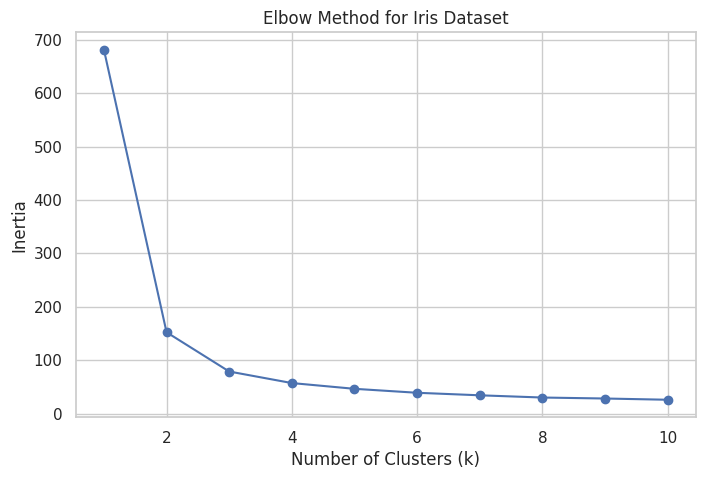

In [30]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Iris Dataset')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

### 5. Compare result with elbow method

In [31]:
optimal_k = 3
kmeans_elbow = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
elbow_labels = kmeans_elbow.fit_predict(X)

print('First 20 labels using fixed k=3:', fixed_labels[:20])
print('First 20 labels using elbow method:', elbow_labels[:20])

First 20 labels using fixed k=3: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
First 20 labels using elbow method: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### 6. K-Means using pyclustering library

In [32]:
# If pyclustering is not installed, run this once
# !pip install pyclustering

In [33]:
import numpy
numpy.warnings = warnings

from pyclustering.cluster.kmeans import kmeans
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer

data = X.values.tolist()
initial_centers = kmeans_plusplus_initializer(data, 3).initialize()
kmeans_py = kmeans(data, initial_centers)
kmeans_py.process()
clusters_py = kmeans_py.get_clusters()
centers_py = kmeans_py.get_centers()

print('Clusters from pyclustering K-Means:')
print(clusters_py)
print('Centers:')
print(centers_py)

Clusters from pyclustering K-Means:
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], [52, 77, 100, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 115, 116, 117, 118, 120, 122, 124, 125, 128, 129, 130, 131, 132, 134, 135, 136, 137, 139, 140, 141, 143, 144, 145, 147, 148], [50, 51, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 106, 113, 114, 119, 121, 123, 126, 127, 133, 138, 142, 146, 149]]
Centers:
[[5.005999999999999, 3.428000000000001, 1.4620000000000002, 0.2459999999999999], [6.8500000000000005, 3.073684210526315, 5.742105263157893, 2.0710526315789473], [5.901612903225807, 2.748387096774194, 4.393548387096775, 1.4338709677419357]]


# Exercise 2: Implement K-Medoids Clustering on Iris Dataset

### 1. Apply K-Medoids on iris dataset

In [34]:
from pyclustering.cluster.kmedoids import kmedoids

data = X.values.tolist()
initial_medoids = [0, 50, 100]

kmedoids_instance = kmedoids(data, initial_medoids)
kmedoids_instance.process()

medoid_clusters = kmedoids_instance.get_clusters()
final_medoids = kmedoids_instance.get_medoids()

print('K-Medoids clusters:')
print(medoid_clusters)
print('Final medoids:', final_medoids)

K-Medoids clusters:
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], [50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 106, 113, 114, 119, 121, 123, 126, 127, 133, 134, 138, 142, 146, 149], [100, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 115, 116, 117, 118, 120, 122, 124, 125, 128, 129, 130, 131, 132, 135, 136, 137, 139, 140, 141, 143, 144, 145, 147, 148]]
Final medoids: [7, 78, 143]


# Exercise 3: Implement PCA on Given Matrix

### 1. Given matrix

In [35]:
matrix = np.array([[2, 3, 4],
                   [3, 5, 6],
                   [5, 8, 9],
                   [6, 9, 11],
                   [7, 10, 13]])

print('Original Matrix:')
print(matrix)

Original Matrix:
[[ 2  3  4]
 [ 3  5  6]
 [ 5  8  9]
 [ 6  9 11]
 [ 7 10 13]]


### 2. Apply PCA

In [36]:
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(matrix)

pca_matrix = PCA(n_components=2)
matrix_pca = pca_matrix.fit_transform(matrix_scaled)

print('PCA transformed matrix:')
print(matrix_pca)
print('Explained variance ratio:', pca_matrix.explained_variance_ratio_)

PCA transformed matrix:
[[-2.50900547 -0.10301605]
 [-1.40115835  0.03754702]
 [ 0.41652909  0.18599234]
 [ 1.30338794  0.02182301]
 [ 2.19024679 -0.14234632]]
Explained variance ratio: [0.99519005 0.00449026]


# Exercise 4: Implement PCA with Wine Dataset

### 1. Load wine dataset

In [37]:
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_target = wine.target

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### 2. Standardize data and apply PCA

In [38]:
wine_scaler = StandardScaler()
wine_scaled = wine_scaler.fit_transform(wine_df)

wine_pca = PCA(n_components=2)
wine_pca_result = wine_pca.fit_transform(wine_scaled)

pca_wine_df = pd.DataFrame(wine_pca_result, columns=['PC1', 'PC2'])
pca_wine_df['Target'] = wine_target

pca_wine_df.head()

,PC1,PC2,Target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


### 3. Plot PCA result

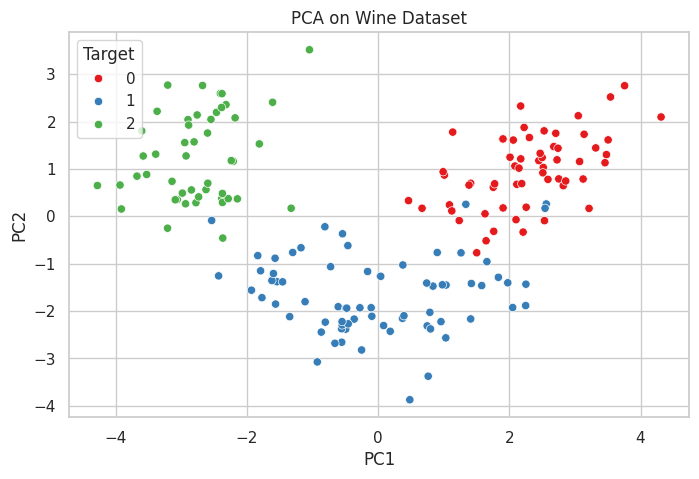

Explained variance ratio: [0.36198848 0.1920749 ]


In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_wine_df, x='PC1', y='PC2', hue='Target', palette='Set1')
plt.title('PCA on Wine Dataset')
plt.show()

print('Explained variance ratio:', wine_pca.explained_variance_ratio_)